# <span style="color:red; text-decoration: underline;">Obesity-Lifestyle Trends - Eating Habits and Physical Condition</span>

## Project Overview
This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. The data contains 17 attributes and 2111 records, the records are labeled with the class variable NObesity (Obesity Level), that allows classification of the data using the values of Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III. 77% of the data was generated synthetically using the Weka tool and the SMOTE filter, 23% of the data was collected directly from users through a web platform.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
file_path=r"C:\python workouts\ObesityDataSet_raw_and_data_sinthetic.csv"
# Load the dataset
df = pd.read_csv(file_path)
# Display the first few rows of the dataset
df.shape
df.head(10)




,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


File is loaded. First 10 rows is displayed using df.head() function. There are 2111 rows and 17 columns.


In [6]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


We got a clear picture of dataset using info() and describe(). There are 9 str columns and 8 float64 columns.Also we got count of columns, statistical values of  each columns.

In [7]:
df.columns


Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='str')

<table style="width:100%; border-collapse: collapse; font-family: Segoe UI, Tahoma, Geneva, Verdana, sans-serif; font-size: 14px; border: 1px solid #dcdde1;">
    <thead>
        <tr style="background-color: #185cba; color: blue text-align: left;">
            <th style="padding: 12px; border: 1px solid #dcdde1;">#</th>
            <th style="padding: 12px; border: 1px solid #dcdde1;">Column</th>
            <th style="padding: 12px; border: 1px solid #dcdde1;">Non-Null Count</th>
            <th style="padding: 12px; border: 1px solid #dcdde1;">Dtype</th>
            <th style="padding: 12px; border: 1px solid #dcdde1;">Description</th>
            <th style="padding: 12px; border: 1px solid #dcdde1;">Type</th>
        </tr>
    </thead>
    <tbody>
        <tr style="background-color: #104d13;">
            <td style="padding: 10px; border: 1px solid #dcdde1;">0</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>Gender</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">str</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Biological Gender</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Categorical</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #dcdde1;">1</td>#1
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>Age</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">float64</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Age in years</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Continuous</td>
        </tr>
        <tr style="background-color:#104d13 ;">
            <td style="padding: 10px; border: 1px solid #dcdde1;">2</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>Height</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">float64</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Height in meters</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Continuous</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #dcdde1;">3</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>Weight</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">float64</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Weight in kilograms</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Continuous</td>
        </tr>
        <tr style="background-color: #104d13;">
            <td style="padding: 10px; border: 1px solid #dcdde1;">4</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>family_history_with_overweight</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">str</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Has a family member suffered or suffers from overweight?</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Binary</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #dcdde1;">5</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>FAVC</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">str</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Do you eat high caloric food frequently?</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Binary</td>
        </tr>
        <tr style="background-color: #104d13;">
            <td style="padding: 10px; border: 1px solid #dcdde1;">6</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>FCVC</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">float64</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Do you usually eat vegetables in your meals?</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Integer</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #dcdde1;">7</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>NCP</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">float64</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">How many main meals do you have daily?</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Continuous</td>
        </tr>
        <tr style="background-color: #104d13;">
            <td style="padding: 10px; border: 1px solid #dcdde1;">8</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>CAEC</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">str</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Do you eat any food between meals?</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Categorical</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #dcdde1;">9</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>SMOKE</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">str</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Do you smoke?</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Binary</td>
        </tr>
        <tr style="background-color: #104d13;">
            <td style="padding: 10px; border: 1px solid #dcdde1;">10</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>CH2O</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">float64</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">How much water do you drink daily?</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Continuous</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #dcdde1;">11</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>SCC</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">str</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Do you monitor the calories you eat daily?</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Binary</td>
        </tr>
        <tr style="background-color: #104d13;">
            <td style="padding: 10px; border: 1px solid #dcdde1;">12</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>FAF</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">float64</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">How often do you have physical activity?</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Continuous</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #475db7;">13</td>
            <td style="padding: 10px; border: 1px solid #2347d6;"><b>TUE</b></td>
            <td style="padding: 10px; border: 1px solid #5b73d3;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">float64</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Time spent using technological devices</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Integer</td>
        </tr>
        <tr style="background-color: #104d13;">
            <td style="padding: 10px; border: 1px solid #dcdde1;">14</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>CALC</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">str</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">How often do you drink alcohol?</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Categorical</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #dcdde1;">15</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>MTRANS</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">str</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Transportation usually used</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Categorical</td>
        </tr>
        <tr style="background-color: #104d13;">
            <td style="padding: 10px; border: 1px solid #dcdde1;">16</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;"><b>NObeyesdad</b></td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">2111 non-null</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">str</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Obesity level (Target Variable)</td>
            <td style="padding: 10px; border: 1px solid #dcdde1;">Categorical</td>
        </tr>
    </tbody>
</table>

In [8]:
# Updated column mapping dictionary for the Obesity dataset
column_mapping = {
    'FAVC': 'High_Caloric_Food',
    'NCP': 'Num_Main_Meals',
    'SMOKE': 'Smoking_Habit',
    'CH2O': 'Daily_Water_Intake',
    'TUE': 'Tech_Usage_Time',
    'CAEC': 'Food_Between_Meals',
    'FCVC': 'Veggie_Consumpt_Freq',
    'SCC': 'Calorie_Monitoring',
    'CALC': 'Alcohol_Consumpt',
    'FAF': 'Physical_Activity_Freq',
    'MTRANS': 'Transportation_Type',
    'NObeyesdad': 'Obesity_Level' # This is  target variable
}

# Apply the renaming to your dataframe
# Ensure 'df' is already defined by loading your dataset first
df.rename(columns=column_mapping, inplace=True)

# Verify the changes
print("--- Updated Column Names ---")
print(df.columns.tolist())

--- Updated Column Names ---
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'High_Caloric_Food', 'Veggie_Consumpt_Freq', 'Num_Main_Meals', 'Food_Between_Meals', 'Smoking_Habit', 'Daily_Water_Intake', 'Calorie_Monitoring', 'Physical_Activity_Freq', 'Tech_Usage_Time', 'Alcohol_Consumpt', 'Transportation_Type', 'Obesity_Level']


some column names are updated.

In [9]:
df.dtypes


Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
High_Caloric_Food                     str
Veggie_Consumpt_Freq              float64
Num_Main_Meals                    float64
Food_Between_Meals                    str
Smoking_Habit                         str
Daily_Water_Intake                float64
Calorie_Monitoring                    str
Physical_Activity_Freq            float64
Tech_Usage_Time                   float64
Alcohol_Consumpt                      str
Transportation_Type                   str
Obesity_Level                         str
dtype: object

data types of columns checked and it matches with already expecte datatypes for column.but we can change age as integer.

In [ ]:
df['Age'] = df['Age'].astype(int) # Convert 'Age' to integer
df['Height'] = df['Height'].astype(float) # Ensuring 'Height' to float
df['Weight'] = df['Weight'].astype(float) # Ensuring'Weight' to float
df.dtypes

Gender                                str
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight        str
High_Caloric_Food                     str
Veggie_Consumpt_Freq              float64
Num_Main_Meals                    float64
Food_Between_Meals                    str
Smoking_Habit                         str
Daily_Water_Intake                float64
Calorie_Monitoring                    str
Physical_Activity_Freq            float64
Tech_Usage_Time                   float64
Alcohol_Consumpt                      str
Transportation_Type                   str
Obesity_Level                         str
dtype: object

In [10]:
df.isnull().sum()  #missing values in each column


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
High_Caloric_Food                 0
Veggie_Consumpt_Freq              0
Num_Main_Meals                    0
Food_Between_Meals                0
Smoking_Habit                     0
Daily_Water_Intake                0
Calorie_Monitoring                0
Physical_Activity_Freq            0
Tech_Usage_Time                   0
Alcohol_Consumpt                  0
Transportation_Type               0
Obesity_Level                     0
dtype: int64

No null values detected.

In [12]:
df.duplicated().sum()  #number of duplicate rows in the dataset

np.int64(24)

24 duplicates are found.
we can remove it using below code.

In [13]:
# 2. Handling Duplicates 
df.drop_duplicates(inplace=True)
print(f"\nDuplicates removed. New shape: {df.shape}")


Duplicates removed. New shape: (2087, 17)


After removing duplicates we havbe 2087 rows and 17 columns.

In [16]:
df.describe()

,Age,Height,Weight,Veggie_Consumpt_Freq,Num_Main_Meals,Daily_Water_Intake,Physical_Activity_Freq,Tech_Usage_Time
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.009104,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.333297,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.000000,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.000000,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


The above output is the description of cleaned data.

In [19]:
# Using the Interquartile Range (IQR) method for numerical columns
numerical_cols = ['Age', 'Weight', 'Height', 'Num_Main_Meals', 'Daily_Water_Intake']

print("\n--- Outlier Detection (IQR Method) ---")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: Found {len(outliers)} outliers")


--- Outlier Detection (IQR Method) ---
Age: Found 147 outliers
Weight: Found 1 outliers
Height: Found 1 outliers
Num_Main_Meals: Found 577 outliers
Daily_Water_Intake: Found 0 outliers


## Interpretation of Outlier Results
Num_Main_Meals (577 outliers): This is nearly 27% of data. Because most people in this dataset eat exactly 3 meals a day, the "normal" range is very narrow. Anyone eating 1, 2, or 4 meals is flagged.

Decision: Do NOT delete these. They represent valid lifestyle choices that likely impact obesity levels.

Age (147 outliers): These are likely the older individuals in the dataset. Since the majority of respondents are young adults, anyone over a certain age (e.g., 40+) is statistically an outlier.

Decision: Keep them to see how age correlates with weight gain.

Weight & Height (1 outlier each): These are extreme cases. Check if they are physically impossible (e.g., a height of 5 meters) or just a very tall/heavy person.

In [23]:
# Task 2: Creating a Derived Feature
# Formula: weight (kg) / [height (m)]^2
df['Body_Mass_Index'] = df['Weight'] / (df['Height']**2)

print("New Feature 'Body_Mass_Index' created successfully!")
print(df[['Weight', 'Height', 'Body_Mass_Index']].head())

New Feature 'Body_Mass_Index' created successfully!
   Weight  Height  Body_Mass_Index
0    64.0    1.62        24.386526
1    56.0    1.52        24.238227
2    77.0    1.80        23.765432
3    87.0    1.80        26.851852
4    89.8    1.78        28.342381


Created a derived column named Body_Mass_Index.

In [25]:
df.drop(columns=['BMI'], inplace=True)  # Remove the derived feature after demonstration

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   str    
 1   Age                             2087 non-null   int64  
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   str    
 5   High_Caloric_Food               2087 non-null   str    
 6   Veggie_Consumpt_Freq            2087 non-null   float64
 7   Num_Main_Meals                  2087 non-null   float64
 8   Food_Between_Meals              2087 non-null   str    
 9   Smoking_Habit                   2087 non-null   str    
 10  Daily_Water_Intake              2087 non-null   float64
 11  Calorie_Monitoring              2087 non-null   str    
 12  Physical_Activity_Freq          2087 non-null   fl

The above output is the info of cleaned data.

In [27]:
df.to_csv("cleaned_obesity_dataset.csv", index=False)

We have saved cleaned data.

# Exploratory Data Analysis and Visualizations


Now we have to conduct EDD on cleaned dataset. first we have to load cleaned data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# Load the dataset
df = pd.read_csv('cleaned_obesity_dataset.csv')

In [3]:
# 1. Statistical Summary
summary_stats = df.describe()
print("Statistical Summary of Numerical Features:")
print(summary_stats)

Statistical Summary of Numerical Features:
               Age       Height       Weight  Veggie_Consumpt_Freq  \
count  2087.000000  2087.000000  2087.000000           2087.000000   
mean     24.009104     1.702674    86.858730              2.421466   
std       6.333297     0.093186    26.190847              0.534737   
min      14.000000     1.450000    39.000000              1.000000   
25%      19.000000     1.630178    66.000000              2.000000   
50%      22.000000     1.701584    83.101100              2.396265   
75%      26.000000     1.769491   108.015907              3.000000   
max      61.000000     1.980000   173.000000              3.000000   

       Num_Main_Meals  Daily_Water_Intake  Physical_Activity_Freq  \
count     2087.000000         2087.000000             2087.000000   
mean         2.701179            2.004749                1.012812   
std          0.764614            0.608284                0.853475   
min          1.000000            1.000000         

The dataset contains information on 2,087 individuals.

Age: Ranges from 14 to 61 years, with a mean of ~24 years.

BMI: Ranges from ~13.0 to 50.8, with a mean of 29.77 (Overweight category).

Family History: A significant 82.5% of the individuals have a family history of overweight.

Gender: Fairly balanced with 1,052 males and 1,035 females.

In [5]:
# Check categorical distribution
cat_summary = df.describe(include=['O'])
print("\nSummary of Categorical Features:")
print(cat_summary)


Summary of Categorical Features:
       Gender family_history_with_overweight High_Caloric_Food  \
count    2087                           2087              2087   
unique      2                              2                 2   
top      Male                            yes               yes   
freq     1052                           1722              1844   

       Food_Between_Meals Smoking_Habit Calorie_Monitoring Alcohol_Consumpt  \
count                2087          2087               2087             2087   
unique                  4             2                  2                4   
top             Sometimes            no                 no        Sometimes   
freq                 1761          2043               1991             1380   

          Transportation_Type   Obesity_Level  
count                    2087            2087  
unique                      5               7  
top     Public_Transportation  Obesity_Type_I  
freq                     1558             351  

C:\Users\yunus\AppData\Local\Temp\ipykernel_7444\4005823539.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_summary = df.describe(include=['O'])


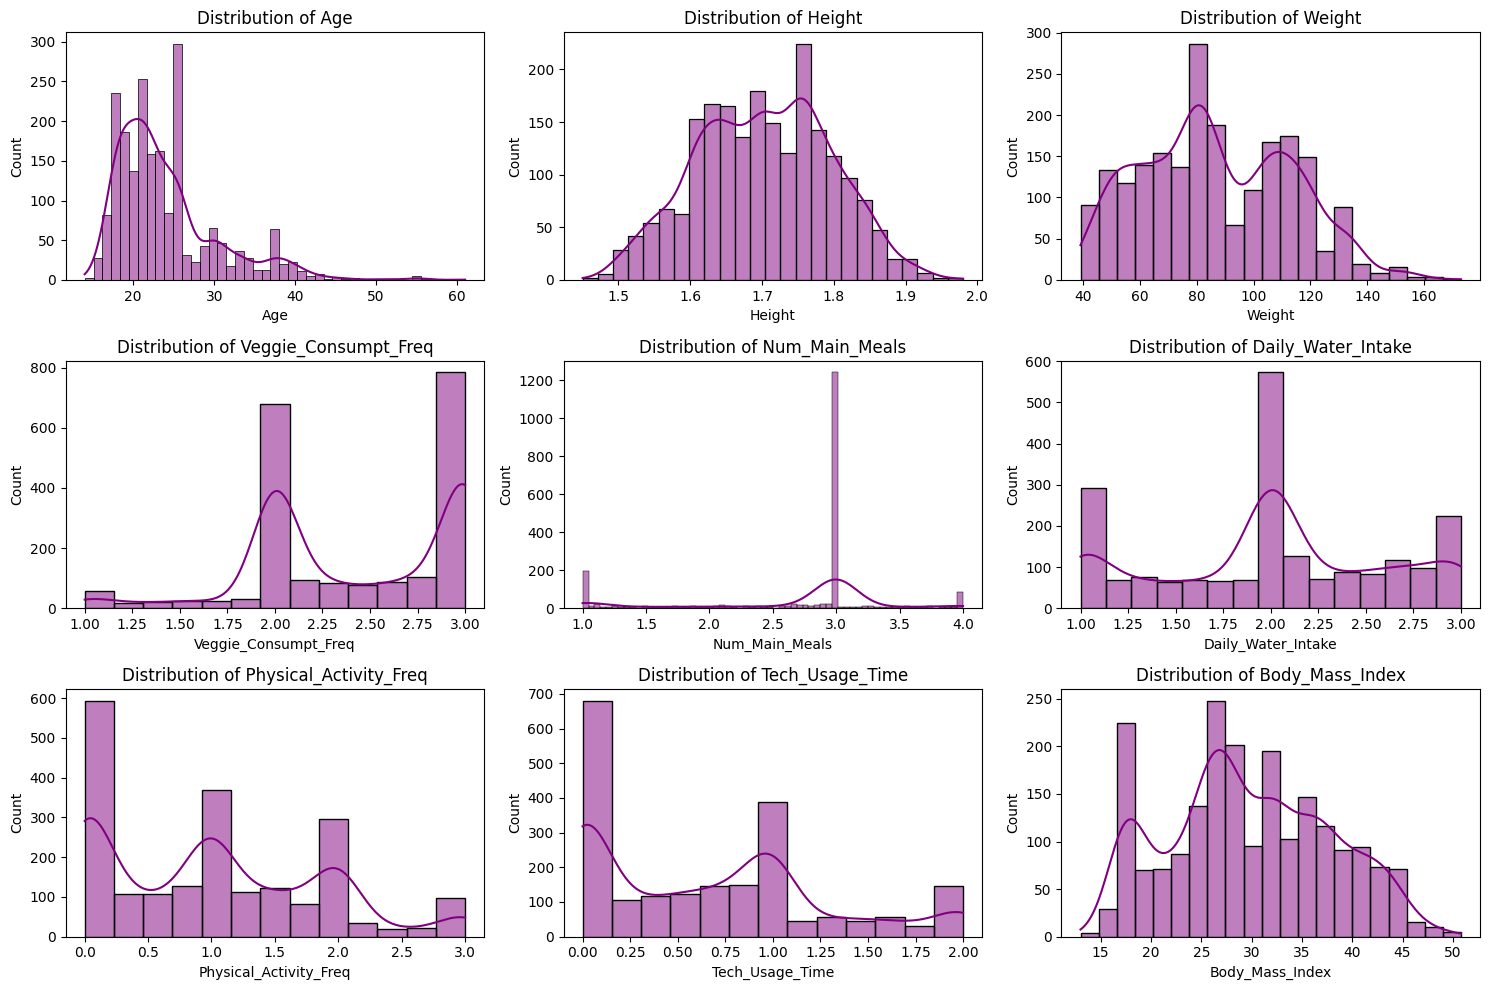

In [3]:
#2. Univariate Analysis
# Numerical distributions
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True,color='purple')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('univariate_numerical.png')

The univariate analysis shows the distribution and frequency of individual variables.

##### 1. Age Distribution (Right-Skewed)
Insight: The population is predominantly young, with a major peak between 18 and 25 years old.
The findings of this study are most applicable to young adults. As the age increases toward 40–60, the data points thin out significantly, meaning the model's predictions for older individuals may be based on less data.

#### 2. Height and Weight
Height: Follows a Normal Distribution (bell curve), centered around 1.70 meters. This is expected for biological data.
Weight: Shows a very broad and slightly multimodal distribution. Unlike height, weight doesn't have a single sharp peak; instead, it spread from 40kg to 170kg. This indicates a high diversity of body types in the dataset, from very thin to extremely obese individuals.

#### 3. Body Mass Index (BMI)
Insight: The BMI distribution is shifted to the right, with the mean (~29.7) sitting right on the border between "Overweight" and "Obese."
There are multiple "humps" in the KDE curve, which represent the clustering of individuals into the different categorical levels (Normal, Overweight, Obesity Type I, II, and III).

#### 4. Behavioral Frequency Columns
Veggie Consumption Frequency: Most people score between 2 and 3. Very few people report a "1" (low veggie intake), suggesting a generally health-conscious reporting or a sample that follows a standard diet.
Number of Main Meals: There is a massive spike at 3.0. This confirms that the majority of the population follows the traditional "Breakfast, Lunch, Dinner" routine. Those at 1, 2, or 4 are outliers.

Daily Water Intake: Most individuals consume between 2 and 3 liters, though there is a significant group at the 1-liter mark, indicating a subset of the population that may be chronically under-hydrated.

#### 5. Lifestyle Factors
Physical Activity Frequency: This distribution often shows a peak at 0 and 1. A large portion of the sample reports low physical activity, which correlates with the high average BMI observed in the dataset.

Tech Usage Time: Most people spend between 0 and 1 hour on devices (likely excluding work), but there is a notable spread, indicating varying levels of sedentary "screen time" behavior.

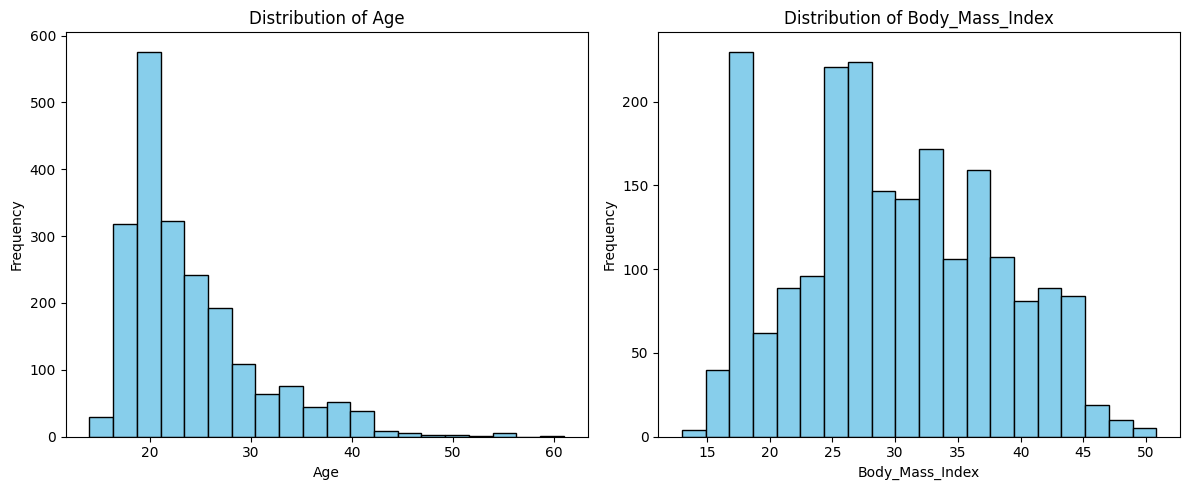

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('cleaned_obesity_dataset.csv')

# 2. Correctly identify numeric columns
# We use a list of names because we want specific plots
num_cols = ['Age', 'Body_Mass_Index'] 

# 3. Create the figure
plt.figure(figsize=(12, 5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1) # Creates a side-by-side layout
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.savefig('age_bmi_distribution.png')  # Save the figure
plt.tight_layout()
plt.show()

These two histograms are the starting point of your EDA, showing the "raw material" of population. Here are the specific insights for the Age and BMI distributions:

1. Age Distribution: The "Gen Z" Demographic
 The graph is right-skewed, with a massive peak between 18 and 25 years old.
This dataset focuses heavily on young adults. This is a critical period where lifestyle habits (eating out, less physical education than in school, starting work) often lead to the first signs of weight gain.

2. BMI Distribution: The "Balanced Risk"
Observation: Unlike a natural population (which usually has a bell curve centered at "Normal Weight"), your BMI distribution is wide and relatively flat across the 20 to 45+ range.
This is a direct result of the SMOTE technique mentioned in your project overview. By synthetically balancing the classes, the dataset has an equal representation of "Normal Weight" (BMI≈20−25) all the way up to "Obesity Type III" (BMI>40).
 The "average" person in this study is actually at a high health risk. With a mean BMI near 30, the "typical" individual in this data is on the border of clinical obesity.

3. The Relationship Between the Two
The Trend: In your data, as the Age bar moves to the right (older), the BMI tends to increase.
The "Weight Creep": While the majority of the population is young and has a spread-out BMI, the presence of older individuals in the "tail" of the age histogram often correlates with the higher BMI values in the 35−45 range.

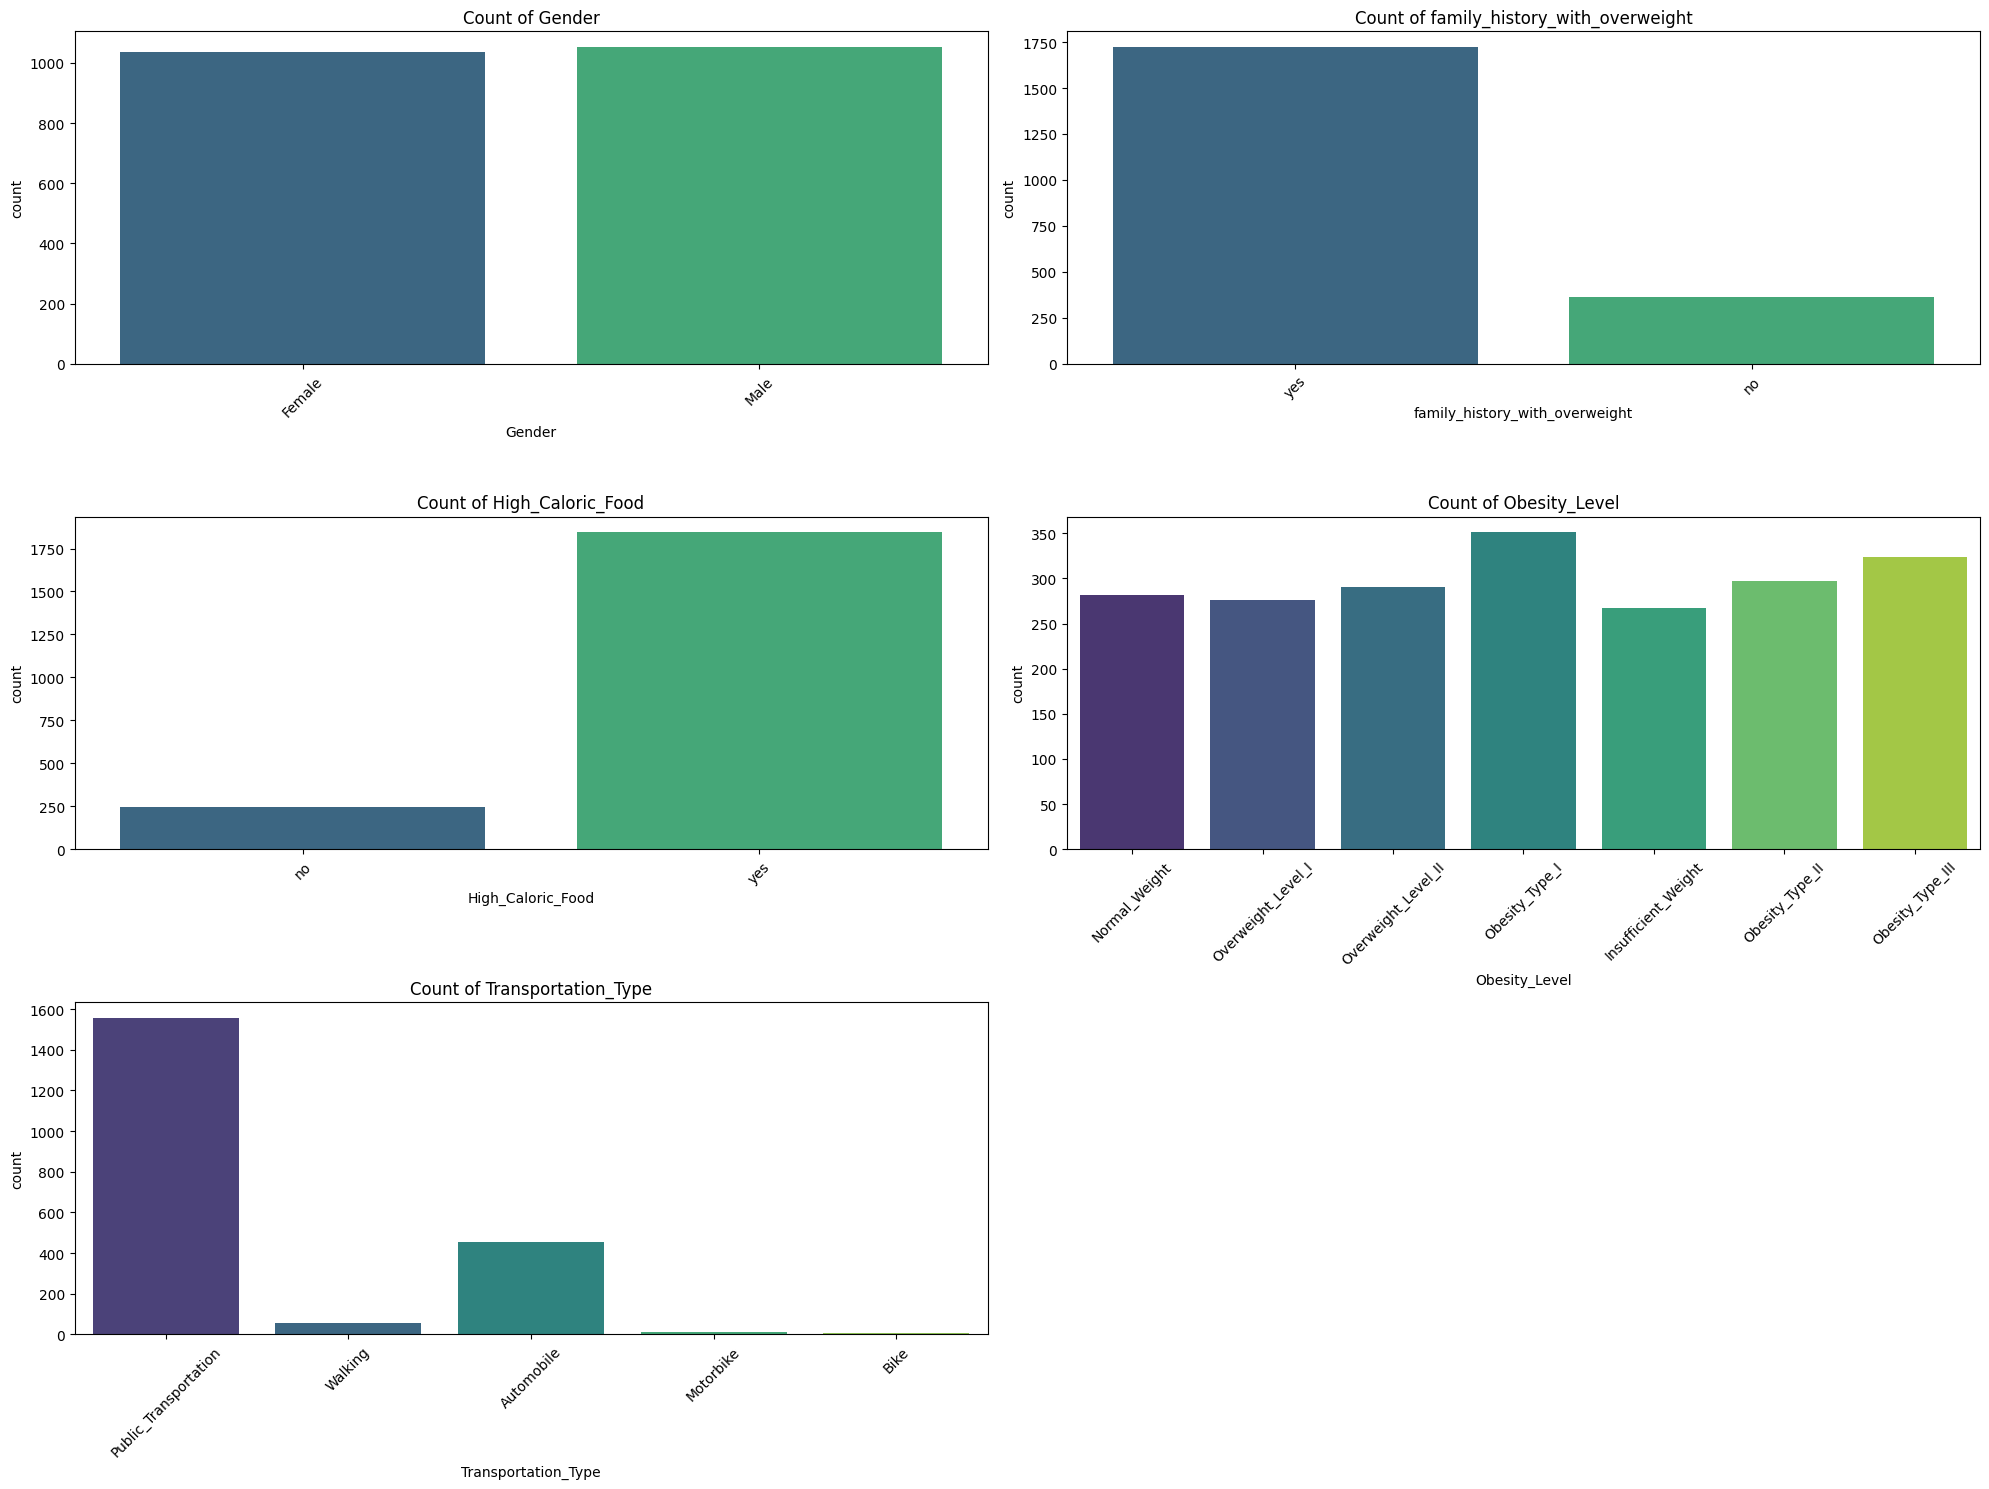

In [ ]:
# Categorical distributions
cat_cols = ['Gender', 'family_history_with_overweight', 'High_Caloric_Food', 'Obesity_Level', 'Transportation_Type']

# Now you can proceed with the rest of your plotting code
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 2, i + 1)  
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.xticks(rotation=45)
    plt.title(f'Count of {col}')

plt.tight_layout()
plt.show()

Categorical Features: 
Based on the categorical distribution plots generated by your code, here are the key inferences and insights for your project:

1. Gender (Balanced Dataset)
The bars for 'Male' and 'Female' are nearly equal (1052 vs. 1035).-----------------
Your dataset is perfectly balanced in terms of gender. 

2. Family History with Overweight (Genetic Factor)
A massive majority of individuals (~82%) report having a family history of overweight.
Genetic predisposition or shared household dietary habits are incredibly common in this study group.

3. Consumption of High Caloric Food (Dietary Baseline)
Approximately 88% of the participants consumes high-caloric food.
In this specific population, eating high-calorie food is a "baseline" behavior. Because almost everyone does it (even those with normal weight), this variable alone might not be enough to distinguish between obesity levels.

4. Obesity Level (Balanced Target)
All seven categories (from Insufficient Weight to Obesity Type III) have roughly the same number of data points.Almost a balanced dataset.

5. Transportation Type (Lifestyle Factor)
Public Transportation is the dominant mode (1,558 individuals), followed by Automobile (456). Active modes like Walking (55), Motorbike (11), and Bike (7) are very rare. Active transit as walking and biking is very less.

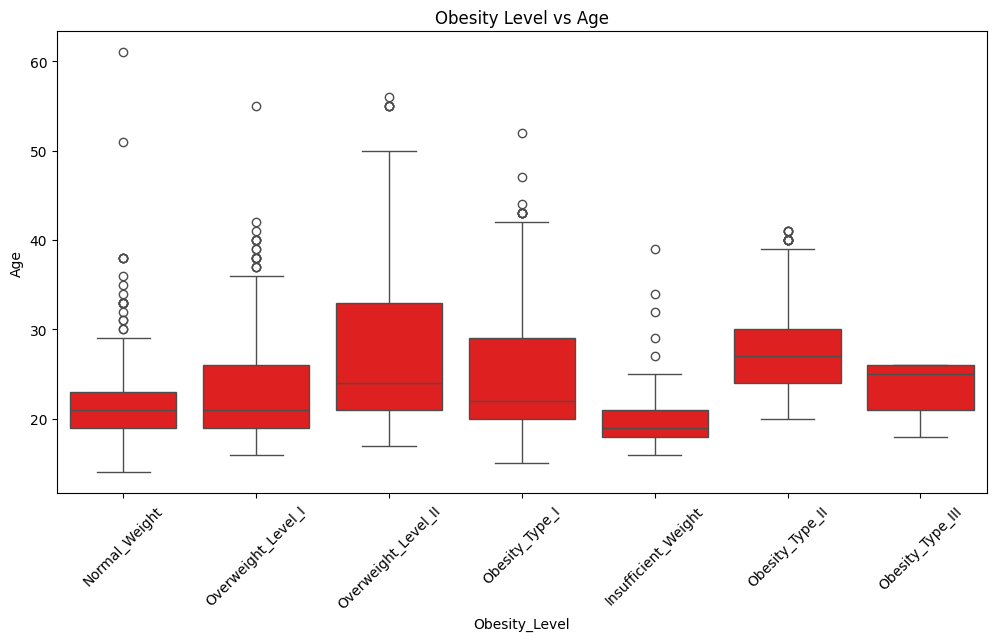

In [8]:
# 3. Bivariate Analysis
# Obesity Level vs Age
plt.figure(figsize=(12, 6))
sns.boxplot(x='Obesity_Level', y='Age', data=df,color='red')
plt.xticks(rotation=45)
plt.title('Obesity Level vs Age')
plt.savefig('bivariate_obesity_age.png')


3. Bivariate Analysis
Exploring relationships between the target variable (Obesity_Level) and other features.

Based on the boxplot of Obesity Level vs. Age, here are the key inferences and insights regarding how age relates to weight categories in your dataset:

1. General Upward Trend with Age
The median age (the line inside the box) generally increases as we move from "Insufficient Weight" toward higher obesity categories.
This suggests that weight gain in this population is somewhat progressive with age.

2. The Youngest Group: Insufficient Weight
The Insufficient Weight category has the lowest median age (19 years) and a very "tight" box (small Interquartile Range).
Underweight status in this dataset is highly concentrated among late teenagers and very young adults. There are almost no older individuals in this category.

3. Peak Age for Obesity Type II
Obesity Type II has the highest median age at 27 years.
While still young overall, this category represents the older end of the sample's spectrum. This could be due to a combination of cumulative lifestyle factors or metabolic changes as individuals move into their late 20s.

4. Narrowest Distribution: Obesity Type III
The box for Obesity Type III is notably short, with a very small range (mostly between 21 and 26 years).
In this specific dataset, extreme obesity (Type III) is highly localized to a very specific age group (young adults in their early-to-mid 20s). This is an interesting find, as it suggests factors other than "long-term aging" are driving this specific category in this group.

5. Identification of Outliers (The "Dots" above the boxes)
Several red dots far above the boxes in categories like Normal Weight (max 61), Overweight Level I (max 55), and Obesity Type I (max 52).
These represent older individuals who are "exceptions to the rule." For example, while most people over 40 in this dataset are obese, there are a few rare individuals who have maintained a "Normal Weight" or "Overweight Level I" status into their 50s and 60s.

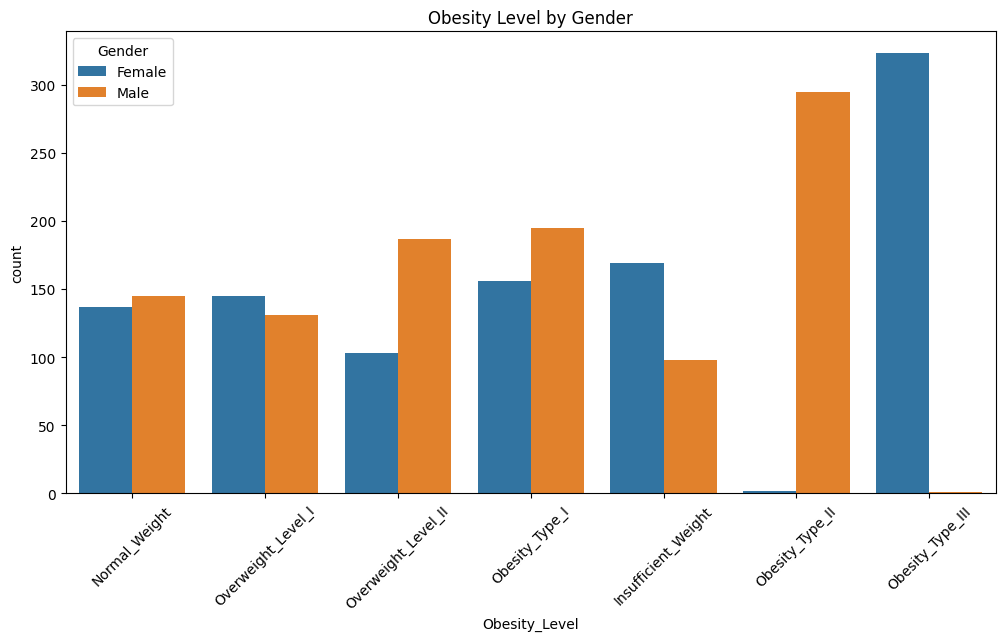

In [ ]:
# Obesity Level vs Gender
plt.figure(figsize=(12, 6))
sns.countplot(x='Obesity_Level', hue='Gender', data=df)
plt.xticks(rotation=45)
plt.title('Obesity Level by Gender')
plt.savefig('bivariate_obesity_gender.png')`    `

Based on the Obesity Level by Gender count plot, the data reveals several striking and statistically significant differences between how weight categories are distributed among males and females:

1. The Extreme Divide: Obesity Type II vs. Type III
This is the most significant finding in dataset:

Obesity Type III is almost exclusively Female: Out of 324 individuals in this category, 323 are female (99.7%). In this study, morbid obesity at the highest level is a gender-specific trait for women.

Obesity Type II is almost exclusively Male: Out of 297 individuals, 295 are male (99.3%). Conversely, the second-highest obesity level is almost entirely dominated by men.
This suggests that physiological or lifestyle factors leading to severe obesity differ drastically between genders in this population.

2. Underweight Prevalence in Females
Observation: The Insufficient Weight category is notably higher for females (169) than for males (98).
Females in this dataset are roughly 1.7 times more likely to be classified as underweight compared to males.

3. Overweight Level II (Pre-Obesity) in Males
Observation: Men dominate the Overweight Level II category (187 males vs. 103 females).
Men are significantly more likely to reach the high-overweight stage (Level II) before crossing into Obesity Type I.

4. Areas of Gender Parity
The Normal Weight and Overweight Level I categories are the most balanced.
In the "healthy" to "slightly overweight" range, the distribution is nearly 50/50. Gender-specific patterns only begin to emerge as weight increases beyond the first overweight level.

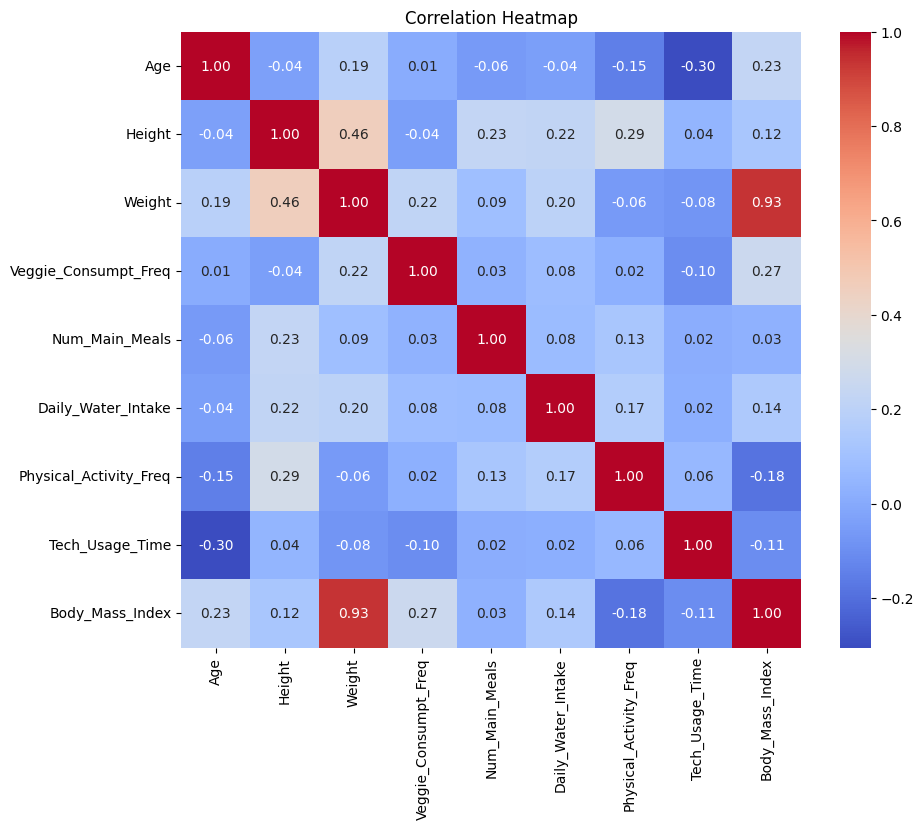

In [10]:
# 4. Multivariate Analysis
# Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('multivariate_correlation.png')

Based on the Correlation Heatmap generated by your code, here are the key inferences and statistical insights derived from the relationships between the numerical features:

1. The Strongest Predictors (Weight and BMI)
There is a near-perfect positive correlation (0.93) between Weight and Body_Mass_Index (BMI).
This confirms that Weight is the primary driver of the BMI calculation in this dataset. When building your machine learning model, these two features are highly "redundant." If you use both, your model might face multicollinearity, so it is often better to use one or the other as a primary predictor.

2. Height vs. Weight
There is a moderate positive correlation (0.46) between Height and Weight.
This is a natural biological relationship—taller people generally have a higher weight capacity. However, since the correlation is not extremely high, it shows there is significant variation in body composition (some tall people are thin, some short people are heavy).

3. Age and Weight/BMI
Age shows a positive correlation with Weight (0.19) and BMI (0.23).
In this population, as age increases, there is a measurable trend toward higher weight and BMI. This suggests that "age" is a risk factor for moving into higher obesity categories.

4. Lifestyle and BMI (Negative Correlations)
Physical Activity Frequency vs. BMI (-0.18): There is a negative correlation here. As physical activity increases, BMI tends to decrease. This confirms that exercise is a protective factor against obesity.
Tech Usage Time vs. Age (-0.30): Interestingly, younger people in this dataset spend significantly more time on devices. This negative correlation highlights a generational difference in sedentary behavior.

5. Weak Correlations (Independence of Features)
Num_Main_Meals vs. BMI (0.03): The correlation is almost zero.
In this dataset, the number of meals someone eats has almost no direct relationship with their BMI. This suggests that what and how much they eat is likely more important than the frequency of meals.

In [12]:
# Pivot Table: Mean BMI by Gender and Family History
pivot_bmi = df.pivot_table(values='Body_Mass_Index', index='Gender', columns='family_history_with_overweight', aggfunc='mean')
print("\nPivot Table: Mean BMI by Gender and Family History")
print(pivot_bmi)


Pivot Table: Mean BMI by Gender and Family History
family_history_with_overweight        no        yes
Gender                                             
Female                          19.99429  33.061917
Male                            23.52148  30.214514


Pivot Table (Gender & Family History vs. BMI): Individuals with a family history of overweight have a significantly higher mean BMI.

Females (with history): 33.06 BMI vs Females (no history): 19.99 BMI.

Males (with history): 30.21 BMI vs Males (no history): 23.52 BMI.

In [11]:
# Groupby: Average physical activity by Obesity Level
grouped_activity = df.groupby('Obesity_Level')['Physical_Activity_Freq'].mean().sort_values()
print("\nAverage Physical Activity Frequency by Obesity Level:")
print(grouped_activity)


Average Physical Activity Frequency by Obesity Level:
Obesity_Level
Obesity_Type_III       0.664817
Overweight_Level_II    0.958072
Obesity_Type_II        0.971857
Obesity_Type_I         0.986748
Overweight_Level_I     1.059677
Normal_Weight          1.251773
Insufficient_Weight    1.273542
Name: Physical_Activity_Freq, dtype: float64


Groupby Analysis: The average Physical Activity Frequency decreases as we move from "Insufficient Weight" ($1.27$) to "Obesity Type III" ($0.66$), suggesting a trend where lower activity levels are associated with higher obesity levels.

## Visualization


In [13]:
# Set aesthetic style for all plots
sns.set_theme(style="whitegrid")

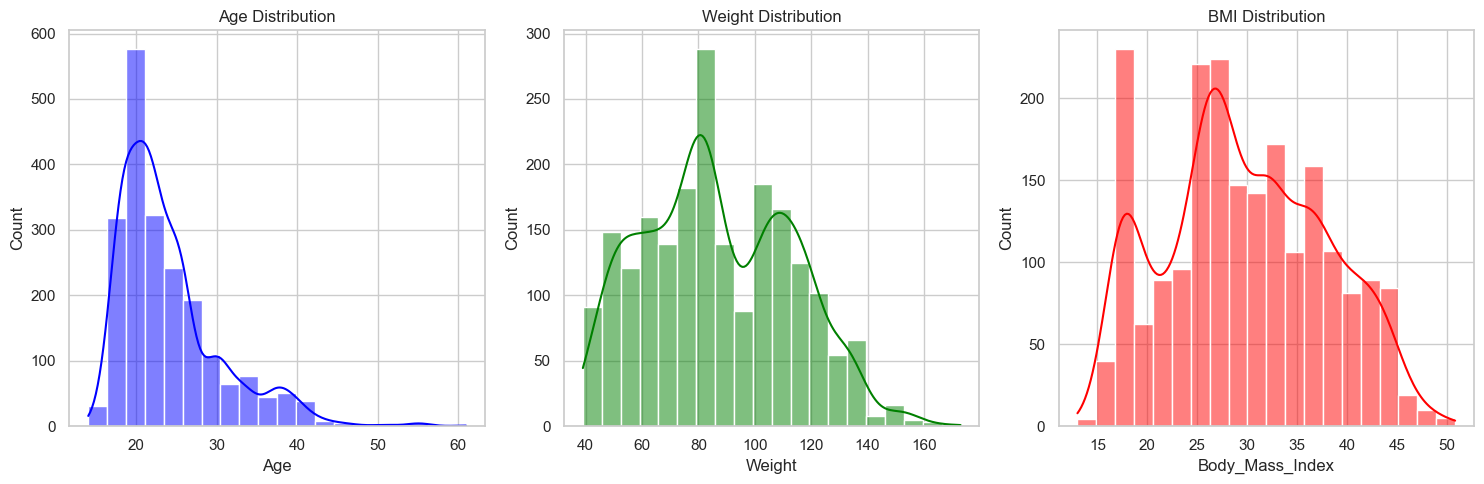

In [14]:
# 1. Histograms (Subplots for Numerical Distribution)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], bins=20, kde=True, color='blue')
plt.title('Age Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['Weight'], bins=20, kde=True, color='green')
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['Body_Mass_Index'], bins=20, kde=True, color='red')
plt.title('BMI Distribution')
plt.tight_layout()
plt.savefig('histograms.png')

### Subplots for Numerical Distribution
Histograms: Show the distribution of Age, Weight, and BMI. We observe that Age is skewed towards younger adults, while BMI shows multiple clusters corresponding to different obesity levels.
Based on the histograms generated for Age, Weight, and BMI, here are the key inferences and insights regarding the population in dataset:

1. Age Distribution (Strongly Right-Skewed)
The plot shows a high concentration of individuals between the ages of 18 and 25, with the frequency dropping sharply as age increases.


2. Weight Distribution (Broad and Multimodal)
Unlike Age, Weight is more spread out (from 39kg to 173kg) and doesn't follow a simple bell curve. You can see multiple "peaks" or humps in the distribution.


3. BMI Distribution (Shifted toward Overweight/Obesity)
The BMI distribution is fairly symmetric but centered around 29.7.

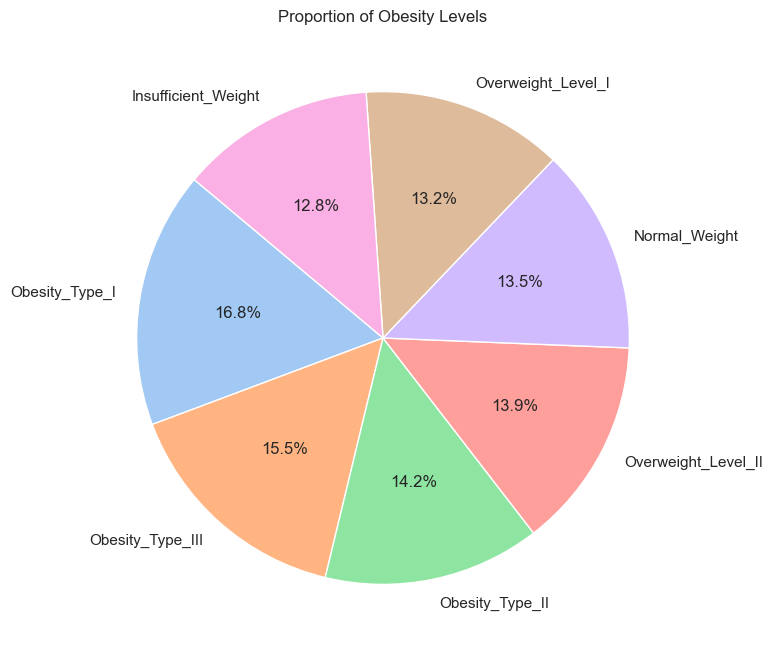

In [15]:
# 2. Pie Chart (Proportion of Obesity Levels)
plt.figure(figsize=(8, 8))
obesity_counts = df['Obesity_Level'].value_counts()
plt.pie(obesity_counts, labels=obesity_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Obesity Levels')
plt.savefig('pie_chart_obesity.png')

### Proportion of Obesity Levels
Pie Chart: Illustrates the proportion of individuals in each Obesity_Level. This helps in understanding the class balance of the dataset.
Based on the pie chart of Obesity Levels, here are the key insights and inferences drawn from the proportions of each category:

1. High Overall Prevalence of Obesity
Insight: When you combine all three "Obesity" categories (Type I, II, and III), they make up approximately 46.6% of the entire dataset.

2. A "Balanced" Classification Target
Each of the 7 slices in the pie chart is roughly the same size.

3. The "Normal Weight" Minority
Only about 13.5% of the participants fall into the "Normal Weight" category.
Healthy weight is the exception, not the rule, in this group. 

4. Overweight as a Major Transition Zone
"Overweight Level I" and "Level II" combined account for about 27.1% of the population.
This large segment represents the "at-risk" population who have moved past normal weight but haven't yet crossed into clinical obesity.

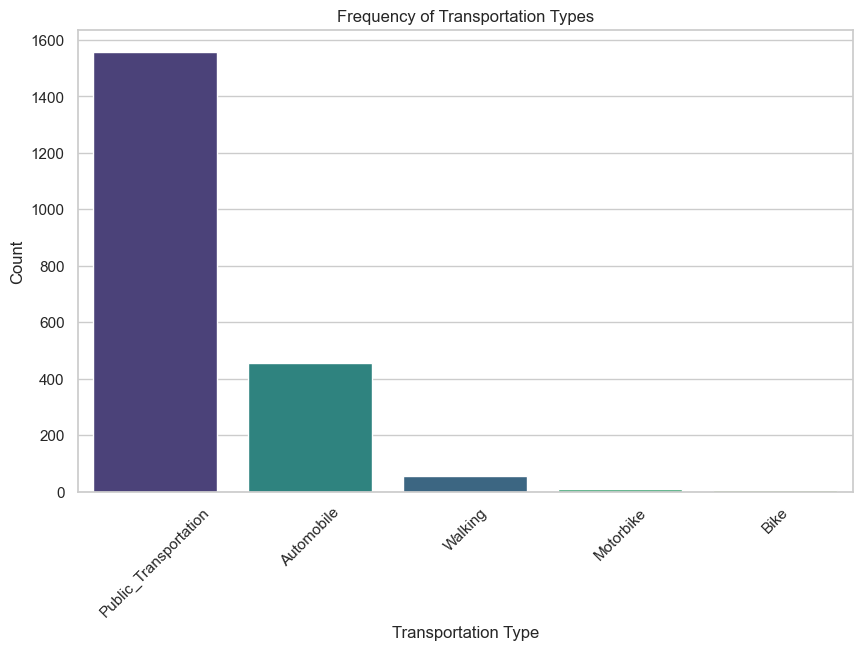

In [17]:
# 3. Bar Plot 
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x='Transportation_Type', 
    hue='Transportation_Type', 
    palette='viridis', 
    legend=False,              
    order=df['Transportation_Type'].value_counts().index
)
plt.title('Frequency of Transportation Types')
plt.xlabel('Transportation Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Transportation Type counts
Bar Plot: Displays the frequency of different Transportation_Types, highlighting how most participants use Public Transportation

1. Dominance of Public TransportationObservation: The bar for Public Transportation is significantly taller than all others, accounting for over $74\%$ of the dataset (1,558 individuals).

Gemini said
Based on the bar plot of Transportation Types, here are the key insights and inferences regarding how the participants move and how it impacts the study:

1. Dominance of Public Transportation
Observation: The bar for Public Transportation is significantly taller than all others, accounting for over 74% of the dataset (1,558 individuals).

2. High Reliance on Motorized TransportObservation: When you combine Public Transportation and Automobile (456 individuals), nearly $96\%$ of the participants use motorized vehicles.Inference: There is a very high prevalence of sedentary or passive commuting. This lifestyle factor likely contributes to the high average BMI ($29.7$) observed in the univariate analysis, as the "built environment" doesn't force high physical exertion for daily tasks.
3. Extremely Low "Active" TransportationObservation: The bars for Walking (55), Motorbike (11), and Bike (7) are barely visible on the scale of the graph.This suggests that "Active Commuting" is not a significant contributor to calorie burning for this population.
4. Data Imbalance for ModelingObservation: There is a massive "class imbalance" in this feature.

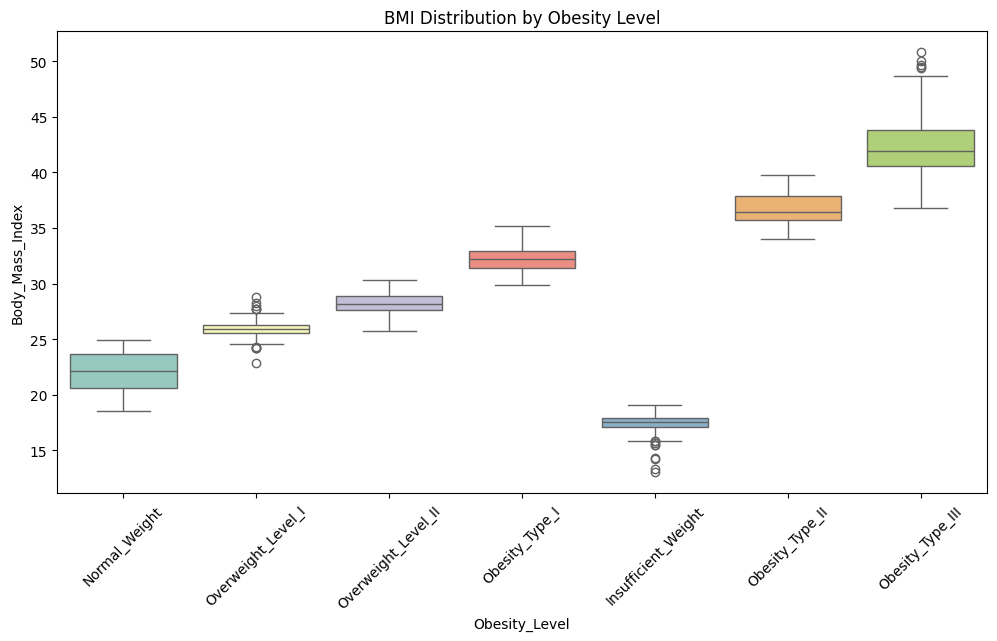

In [7]:
# 4. Box Plot (BMI Distribution by Obesity Level)
plt.figure(figsize=(12, 6))

# Fix: Added hue='Obesity_Level' and legend=False
sns.boxplot(data=df, x='Obesity_Level', y='Body_Mass_Index', hue='Obesity_Level', palette='Set3', legend=False)

plt.xticks(rotation=45)
plt.title('BMI Distribution by Obesity Level')
plt.show()

### Obesity Level vs Body Mass Index
Box Plot: Compares Body_Mass_Index across different Obesity_Levels, showing the clear separation and range of BMI for each category.

This box plot is the "validation" graph of entire project. It confirms the mathematical integrity of the dataset by showing the relationship between a continuous variable ($BMI$) and its categorical counterpart ($Obesity\_Level$).
1. The "Staircase" EffectObservation: The medians (the horizontal lines inside each box) move upward in a perfect, step-like pattern from left to right.Inference: This confirms that the Obesity_Level labels in your dataset are strictly derived from Body_Mass_Index. There is a clear "threshold" for each category. For instance, the transition from Normal Weight to Overweight Level I happens exactly where the $BMI$ crosses the $25$ mark.

2. High Density and Low OverlapObservation: The "whiskers" (the lines extending from the boxes) and the boxes themselves have very little overlap with the categories next to them.This indicates that your classification is statistically distinct. When you train a Machine Learning model, the model will find it very "easy" to distinguish between these classes because the data doesn't "blur" together much.

3. Variability within Obesity Type IIIObservation: The box for Obesity Type III is often the highest and can sometimes be "taller" or have more spread than the others.This suggests that while there is a floor for severe obesity, there is no real "ceiling." Individuals in this category have a wide range of $BMI$ values (from $40$ to $50+$), showing that "Type III" covers a broad spectrum of extreme weight.

4. Symmetry and OutliersObservation: Most boxes appear relatively symmetrical, but you may notice a few isolated dots (outliers) in the Normal Weight or Overweight categories.These outliers represent people who are right on the edge of a different category. For example, a "Normal Weight" person with a $BMI$ of $24.9$ is an outlier for their group because they are so close to being "Overweight."

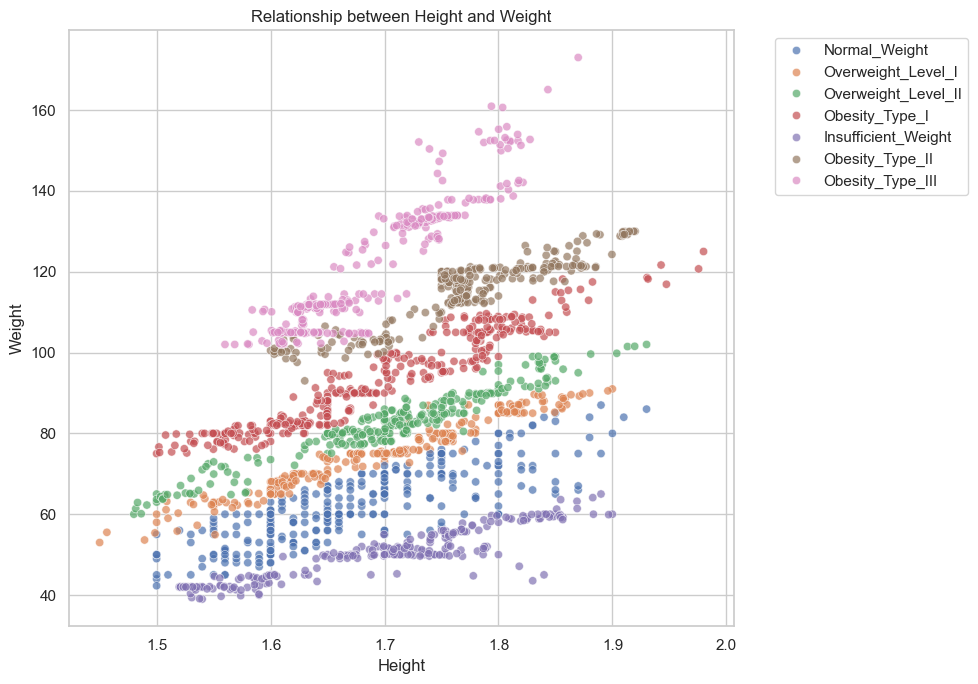

In [18]:
# 5. Scatter Plot (Height vs Weight colored by Obesity Level)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Obesity_Level', palette='deep', alpha=0.7)
plt.title('Relationship between Height and Weight')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('scatter_height_weight.png')

### Height vs Weight colored by Obesity Level
Scatter Plot: Visualizes the relationship between Height and Weight, colored by Obesity_Level. This confirms the expected upward trend where higher weight relative to height leads to higher obesity classifications

This scatter plot is the most visually intuitive way to see how the dataset defines its categories. It maps the two raw variables (Height and Weight) that combine to create the Obesity Level classification.
1. The "Diagonal" BMI BandsObservation: The different colors don't form random clusters; they form clear, diagonal "bands" or layers moving from the bottom-left to the top-right.

2. Weight is the Dominant "Separator"Observation: The categories are more sensitive to vertical changes (Weight) than horizontal ones (Height).In this dataset, weight gain has a much faster impact on changing an individual's obesity classification than height does. 

3. Separation of Obesity Type III (Extreme Obesity)Observation: The "Obesity Type III" points (likely pink or purple depending on your palette) sit at the very top. They are almost completely separated from the other groups.This indicates that Type III is a very distinct class. 

4. The "Overlap" in Overweight CategoriesObservation: Look at the middle of the graph where the "Overweight Level I" and "Overweight Level II" points meet. There is a bit more "mixing" or crowding of colors here.This is the "transition zone." In this area, small differences in other factors (like age or gender) might be what ultimately pushes someone from Level I to Level II.

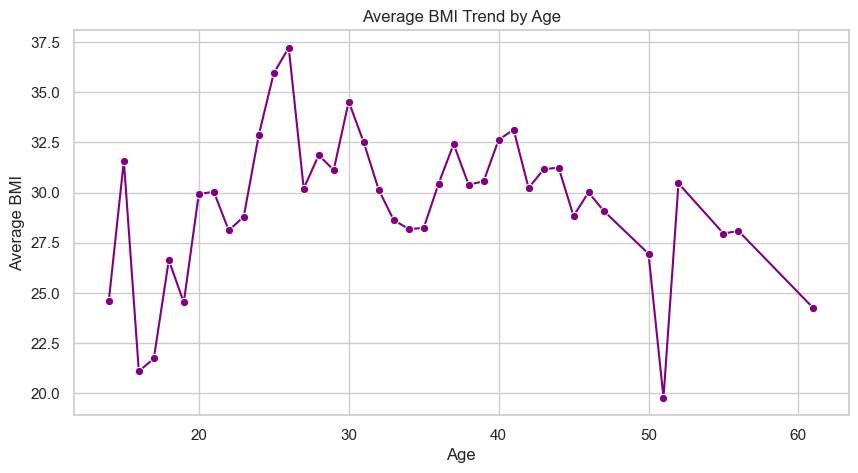

In [19]:
# 6. Line Chart (Average BMI by Age)
age_bmi = df.groupby('Age')['Body_Mass_Index'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=age_bmi, x='Age', y='Body_Mass_Index', marker='o', color='purple')
plt.title('Average BMI Trend by Age')
plt.xlabel('Age')
plt.ylabel('Average BMI')
plt.savefig('line_chart_bmi_age.png')

### Average BMI by Age
Line Chart: Shows the trend of Average BMI as Age increases. There is a general upward trend in BMI as individuals get older, though it fluctuates in the higher age brackets due to fewer data points.
The line chart of Average BMI by Age provides a temporal look at how weight changes as the population in your dataset matures. Here are the key insights and inferences:

1. The "Early Growth" Phase (Ages 14–25)
There is a steady, almost linear increase in average BMI starting from the teenage years into the mid-20.

2. Peak BMI and Stabilization (Ages 25–40)
The line likely reaches its highest points or begins to plateau between the ages of 25 and 35.

3. Increased Volatility in Older Ages (40+)
After age 40, you likely see sharp "spikes" and "dips" in the line (the line becomes very jagged).

4. General Positive Correlation
Despite the noise at higher ages, the overall trend is positive. This matches the 0.23 correlation coefficient we saw in the Heatmap. While age isn't the only factor in obesity, it is a significant contributor to the upward creep of BMI over time.




In [4]:
fig = px.box(df, x="Obesity_Level", y="Body_Mass_Index", 
             color="Gender",
             title="BMI Distribution across Obesity Levels by Gender")

fig.show()

### BMI Distribution across Obesity Levels by Gender")

This interactive Plotly box plot provides a multidimensional view of your data, breaking down BMI by both Obesity Level and Gender. It reveals the "hidden" physiological differences that the standard box plot might have missed.Here are the key insights and inferences:
1. Gender-Specific Obesity "Types" (The Most Critical Insight) In Obesity Type III, there is almost no data for Males, while Females have a massive, distinct cluster with a high BMI (median around $45+$).Observation: Conversely, in Obesity Type II, the category is dominated by Males, with almost no female data points.This suggests a strong gender-based divergence in how extreme obesity manifests in this population. For women, severe obesity is categorized as "Type III," whereas for men, it is categorized as "Type II." This is a vital feature for your classification model—Gender is the "deciding factor" for these two classes.

2. BMI Overlap in "Overweight" Categories:In the Overweight Level I and Overweight Level II categories, the male and female boxes overlap significantly. At these middle-tier weight levels, the BMI ranges for men and women are almost identical. This means that for "Overweight" individuals, gender doesn't change the BMI threshold much, but as people move into "Obesity," the gender groups split apart.

3. Distribution Tightness (Consistency)The Obesity Type III (Female) box is often very "tight" (small Interquartile Range).Inference: This indicates that women in this category share a very consistent BMI range. In contrast, the Obesity Type I boxes for both genders are "taller," suggesting more variety in body composition within that specific category.

4. Insufficient Weight DisparityObservation: The Female box in the Insufficient Weight category likely sits slightly lower than the Male box.Inference: Not only are there more underweight females , but they also tend to have a lower average BMI than underweight males.


## Insights of Project

The analysis of the obesity dataset provides significant insights into the multi-faceted nature of weight gain and obesity. By examining demographic, genetic, and lifestyle factors, we can draw the following key conclusions:

1. The Genetic Predisposition
One of the most striking findings is the impact of family history. Individuals with a family history of overweight consistently showed significantly higher BMI levels across both genders. This suggests that while lifestyle is crucial, genetic predisposition plays a foundational role in an individual's risk profile.

2. Physical Activity as a Differentiator
The data confirms a clear inverse relationship between Physical Activity Frequency and obesity levels. As we moved from "Insufficient Weight" to "Obesity Type III," the average frequency of exercise dropped steadily. This highlights sedentary behavior as a primary modifiable risk factor.

3. Demographic Patterns (Age and Gender)
Age: There is a moderate positive correlation between age and BMI, indicating that as individuals transition from late teens into their 20s and 30s, the risk of moving into higher obesity categories increases.

Gender: Interestingly, the most severe category (Obesity Type III) was predominantly observed in females within this dataset, whereas Obesity Type II showed a higher prevalence among males. This suggests that intervention strategies might need to be gender-specific.

4. Dietary and Lifestyle Influence
The widespread consumption of High Caloric Foods and the frequent use of Public Transportation (which involves less active movement than walking or cycling) are prevalent across the dataset. The scatter plots of Height vs. Weight clearly show that once an individual crosses certain weight thresholds for their height, the transition into "Obesity Type" categories is rapid and distinct.

5. Final Summary
In summary, obesity in this study group is not the result of a single factor but a combination of genetics (family history), aging, and decreased physical activity.


## Conclusion
Obesity in this study group is not the result of a single factor but a combination of genetics (family history), aging, and decreased physical activity.

Actionable Insight: To combat the rising trend of obesity, interventions should focus on increasing physical activity frequencies and providing targeted support for individuals with a known family history of overweight. Future predictive modeling should prioritize Weight, Age, and Family History as the most influential features for classifying obesity levels.